In [ ]:
import os, zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files
from IPython.display import display
import ipywidgets as widgets
from tqdm import tqdm


In [ ]:
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
zip_path = "/content/drive/MyDrive/datasets/archive.zip"  # 🔁 Replace with your actual ZIP path
dataset_root = "/content/fruits"

if not os.path.exists(dataset_root):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_root)
    print("✅ Dataset extracted!")


✅ Dataset extracted!


In [ ]:
subfolders = [f.name for f in os.scandir(dataset_root) if f.is_dir()]
dataset_path = os.path.join(dataset_root, subfolders[0]) if len(subfolders) == 1 else dataset_root
print("✅ Using dataset path:", dataset_path)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
class_names = dataset.classes
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)
print(dataset.class_to_idx)

✅ Using dataset path: /content/fruits
{'fresh_apple': 0, 'fresh_banana': 1, 'fresh_bitter_gourd': 2, 'fresh_capsicum': 3, 'fresh_orange': 4, 'fresh_tomato': 5, 'stale_apple': 6, 'stale_banana': 7, 'stale_bitter_gourd': 8, 'stale_capsicum': 9, 'stale_orange': 10, 'stale_tomato': 11}


In [ ]:
# Patch Embedding
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels=3, patch_size=4, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)  # B, N, C
        return x

# Window Partition / Reverse
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

# Window Attention
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(0.0)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        out = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        out = self.proj(out)
        return out

# Swin Transformer Block
class SwinBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=7, shift_size=0, mlp_ratio=4.0):
        super().__init__()
        self.dim = dim
        self.input_resolution = input_resolution
        self.num_heads = num_heads
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, int(dim * mlp_ratio)),
            nn.GELU(),
            nn.Linear(int(dim * mlp_ratio), dim),
        )

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        assert L == H * W, "Input feature has wrong size"

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        # cyclic shift
        if self.shift_size > 0:
            shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))
        else:
            shifted_x = x

        # partition windows
        x_windows = window_partition(shifted_x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size * self.window_size, C)

        attn_windows = self.attn(x_windows)

        # merge windows
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)

        # reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x.view(B, H * W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))

        return x

# Patch Merging
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()
        self.input_resolution = input_resolution
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)
        self.norm = nn.LayerNorm(4 * dim)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0, x1, x2, x3], -1)
        x = x.view(B, -1, 4 * C)
        x = self.norm(x)
        x = self.reduction(x)

        return x

# Swin Transformer Stage
class BasicLayer(nn.Module):
    def __init__(self, dim, input_resolution, depth, num_heads, window_size, mlp_ratio, downsample=None):
        super().__init__()
        self.blocks = nn.ModuleList([
            SwinBlock(dim, input_resolution, num_heads, window_size,
                      shift_size=0 if i % 2 == 0 else window_size // 2,
                      mlp_ratio=mlp_ratio)
            for i in range(depth)
        ])
        self.downsample = downsample(input_resolution, dim) if downsample else None

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        if self.downsample:
            x = self.downsample(x)
        return x

# Full Swin Transformer Model
class SwinTransformer(nn.Module):
    def __init__(self, img_size=224, patch_size=4, in_channels=3, num_classes=1000,
                 embed_dim=96, depths=[2, 2, 6, 2], num_heads=[3, 6, 12, 24],
                 window_size=7, mlp_ratio=4.0):
        super().__init__()
        self.num_classes = num_classes
        self.embed_dim = embed_dim
        self.patch_embed = PatchEmbedding(in_channels, patch_size, embed_dim)
        self.pos_drop = nn.Dropout(0.0)

        self.layers = nn.ModuleList()
        resolution = (img_size // patch_size, img_size // patch_size)
        dim = embed_dim

        for i in range(len(depths)):
            layer = BasicLayer(
                dim=dim,
                input_resolution=resolution,
                depth=depths[i],
                num_heads=num_heads[i],
                window_size=window_size,
                mlp_ratio=mlp_ratio,
                downsample=PatchMerging if i < len(depths) - 1 else None
            )
            self.layers.append(layer)
            if i < len(depths) - 1:
                resolution = (resolution[0] // 2, resolution[1] // 2)
                dim *= 2

        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.pos_drop(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.head(x)
        return x


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SwinTransformer(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"✅ Epoch {epoch+1}: Loss={total_loss/len(train_loader):.4f}, Accuracy={acc:.2f}%")


Epoch 1: 100%|██████████| 1469/1469 [03:25<00:00,  7.14it/s]


✅ Epoch 1: Loss=0.7934, Accuracy=71.37%


Epoch 2: 100%|██████████| 1469/1469 [03:25<00:00,  7.16it/s]


✅ Epoch 2: Loss=0.3379, Accuracy=87.99%


Epoch 3: 100%|██████████| 1469/1469 [03:25<00:00,  7.16it/s]


...

✅ Epoch 18: Loss=0.0702, Accuracy=97.56%


Epoch 19: 100%|██████████| 1469/1469 [03:25<00:00,  7.16it/s]


✅ Epoch 19: Loss=0.0833, Accuracy=97.28%


Epoch 20: 100%|██████████| 1469/1469 [03:25<00:00,  7.15it/s]

✅ Epoch 20: Loss=0.0857, Accuracy=97.07%


In [ ]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"📊 Test Accuracy: {test_acc:.2f}%")


📊 Test Accuracy: 97.48%


In [ ]:
model_save_path = "/content/fresh_fruit_swin_model.pt"
torch.save(model.state_dict(), model_save_path)

# Copy to Drive
!cp /content/fresh_fruit_swin_model.pt "/content/drive/MyDrive/YourFolder/fresh_fruit_swin_model.pkl"
print("✅ Model saved to Colab and Drive (.pt format)")


cp: cannot create regular file '/content/drive/MyDrive/YourFolder/fresh_fruit_swin_model.pkl': No such file or directory
✅ Model saved to Colab and Drive (.pt format)


In [ ]:
# Upload Button for Testing Image
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io
import torchvision.transforms as transforms

upload_widget = FileUpload(accept='image/*', multiple=False)
display(upload_widget)

def on_upload_change(change):
    for name, file_info in upload_widget.value.items():
        # Load image from uploaded content
        image_bytes = file_info['content']
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        image = image.resize((224, 224))

        # Transform image
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])
        input_tensor = transform(image).unsqueeze(0).to(device)

        # Load model
        model = SwinTransformer(num_classes=len(class_names)).to(device)
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        model.eval()

        with torch.no_grad():
            output = model(input_tensor)
            pred_class = torch.argmax(output, dim=1).item()
            print(f"Predicted class: {class_names[pred_class]}")

upload_widget.observe(on_upload_change, names='value')


FileUpload(value={}, accept='image/*', description='Upload')

Predicted class: stale_orange


FileUpload(value={}, accept='image/*', description='Upload')

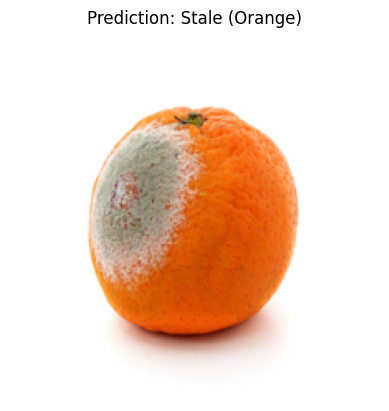

In [ ]:
#single image predection
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

upload_widget = FileUpload(accept='image/*', multiple=False)
display(upload_widget)

def on_upload_change(change):
    for name, file_info in upload_widget.value.items():
        # Load and display image
        image_bytes = file_info['content']
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        image_resized = image.resize((224, 224))

        # Show uploaded image
        plt.imshow(image_resized)
        plt.axis('off')

        # Preprocess image
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
        ])
        input_tensor = transform(image_resized).unsqueeze(0).to(device)

        # Load model
        model = SwinTransformer(num_classes=len(class_names)).to(device)
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        model.eval()

        # Predict
        with torch.no_grad():
            output = model(input_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
            pred_class = class_names[pred_idx]

            # Extract quality (e.g., 'fresh' or 'stale') from class label if formatted like 'fresh_apple'
            if "_" in pred_class:
                fruit, quality = pred_class.split("_", 1)
            else:
                fruit, quality = pred_class, "Unknown"

            plt.title(f"Prediction: {fruit.title()} ({quality.title()})")
            plt.show()

upload_widget.observe(on_upload_change, names='value')


FileUpload(value={}, accept='image/*', description='Upload', multiple=True)

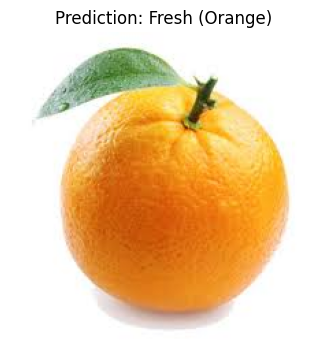

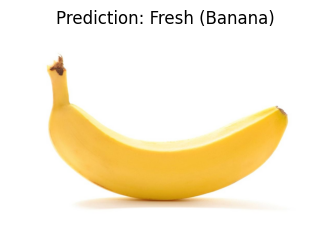

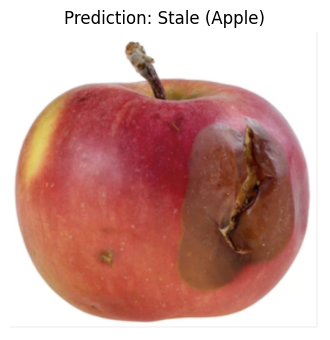

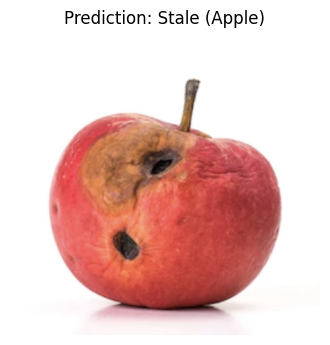

In [ ]:
#multiple image predection
from ipywidgets import FileUpload
from IPython.display import display
from PIL import Image
import io
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch

# File upload widget
upload_widget = FileUpload(accept='image/*', multiple=True)
display(upload_widget)

def on_upload_change(change):
    # Load model
    model = SwinTransformer(num_classes=len(class_names)).to(device)
    model.load_state_dict(torch.load(model_save_path, map_location=device))
    model.eval()

    # Transform
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    for name, file_info in upload_widget.value.items():
        image_bytes = file_info['content']
        image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)

        # Predict
        with torch.no_grad():
            output = model(img_tensor)
            pred_idx = torch.argmax(output, dim=1).item()
            pred_class = class_names[pred_idx]

        # Extract quality if available
        if "_" in pred_class:
            fruit, quality = pred_class.split("_", 1)
        else:
            fruit, quality = pred_class, "Unknown"

        # Display image and prediction
        plt.figure(figsize=(4, 4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Prediction: {fruit.title()} ({quality.title()})")
        plt.show()

upload_widget.observe(on_upload_change, names='value')


In [ ]:
import pickle

# Assuming your model variable is named 'model'
with open("swin_transformer_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [ ]:
# Save architecture in code format (recommended way in PyTorch)
model_architecture = str(model)
with open("swin_architecture.txt", "w") as f:
    f.write(model_architecture)


In [ ]:
# Save model weights
torch.save(model.state_dict(), "swin_weights.pt")


In [ ]:
import torch
import pickle

# Assuming your model is already defined and trained
# For example: model = SwinTransformer(...)

# Save both architecture and weights in one .pkl file
with open("swin_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [ ]:
with open("swin_transformer_model.pkl", "rb") as f:
    model = pickle.load(f)


In [ ]:
import os

checkpoints = [f for f in os.listdir() if f.endswith(".pth")]
print("Saved checkpoints:", checkpoints)
print("Total checkpoints:", len(checkpoints))


Saved checkpoints: []
Total checkpoints: 0
